# RetainIQ — Explainable AI (Local SHAP + LIME Per-Customer Explanations)

CLAUDE.md Sec 14 Phase 3: "SHAP + LIME explainability, plain-English reasons." `src/explain/driver_analysis.py` (`06`) already ranks **global** churn drivers, but from a disposable diagnostic model unrelated to production. `src/models/scoring.py` (`09`)/`src/recommend/risk_tiers.py` (`10`) turn the real, persisted `models/churn_model.pkl` into a calibrated probability and a risk tier, but never explain *why*. This notebook demonstrates `src/explain/local_explainer.py`, which closes that gap: per-customer local SHAP `TreeExplainer` drivers, LIME as the mandated alternative local view, and a second, production-honest global SHAP ranking — all with plain-English reasons.

**Interpretation note — which model is explained:** `shap.TreeExplainer` cannot open a `CalibratedClassifierCV`'s internal 5-fold structure, so both SHAP and LIME here explain the **raw** `churn_model.pkl` pipeline, not the calibrated one `09`'s `score_customers` serves by default. Isotonic calibration reshapes *how confident* a probability is, not *which features* drove it or their *direction* — the calibrated probability shown elsewhere and this notebook's driver explanations are complementary, not required to numerically reconcile.

**Scope note:** this is CLAUDE.md Sec 14 Phase 3 itself (unlike `06`/`09`/`10`, each a bridge or a different phase). No FastAPI `/explain` endpoint, no Streamlit view — Phase 5. See `.claude/specs/11-explainable-ai.md` for the full spec and every verified number below.

In [1]:
import sys
from pathlib import Path

# Allow `import src...` when the notebook is run from notebooks/
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
from IPython.display import Image, display

from src.data.config import FIGURES_DIR
from src.data.load_data import load_clean_data
from src.explain import driver_analysis, local_explainer

pd.set_option("display.max_columns", None)
df = load_clean_data()
context = local_explainer.build_explainer_context(df)
print(f"{len(df)} customers loaded; explaining the persisted {context['model_name']} model")

7043 customers loaded; explaining the persisted XGBoost model


## 1. Global SHAP importance on the production model

A second, production-honest global ranking — computed on the **real, persisted** `churn_model.pkl`'s held-out test split, distinct from `06`'s disposable-diagnostic-model ranking. One-hot dummies are aggregated back to their original column exactly as `06` established.

In [2]:
production_ranking = local_explainer.global_shap_importance(context)
production_ranking

,column,mean_abs_shap
0,Contract,0.8253
1,tenure,0.4628
2,OnlineSecurity,0.2834
3,InternetService,0.2750
4,PaymentMethod,0.2366
5,TechSupport,0.1932
6,PaperlessBilling,0.1482
7,MonthlyCharges,0.1264
8,StreamingMovies,0.1155
9,OnlineBackup,0.1012


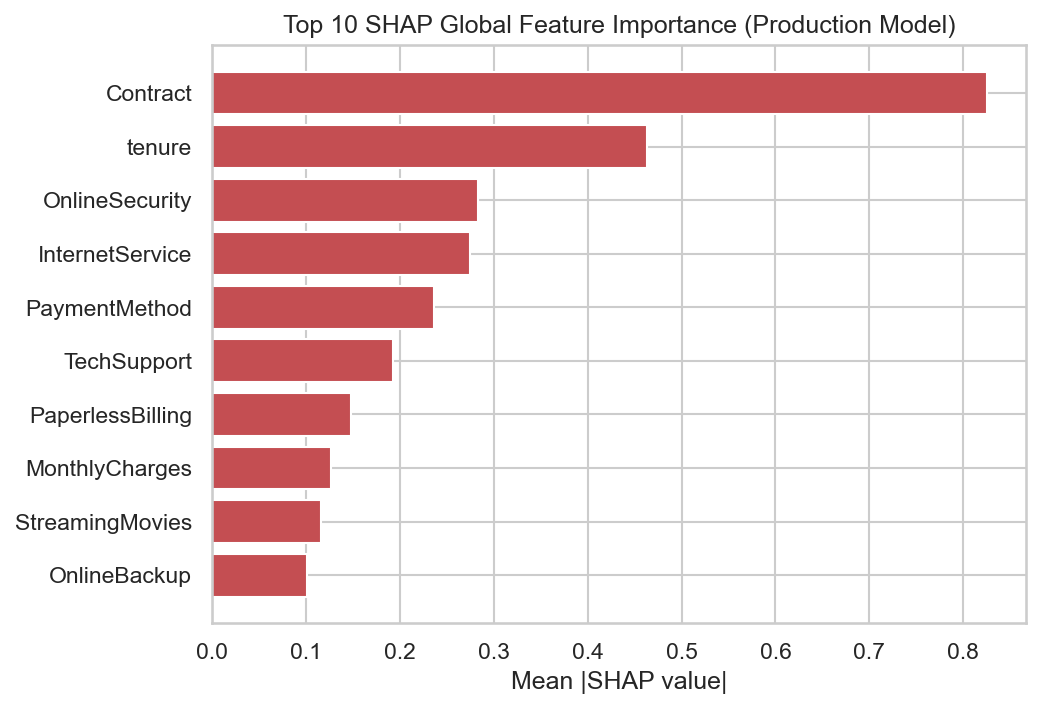

In [3]:
local_explainer.plot_global_shap_importance(context)
display(Image(str(FIGURES_DIR / local_explainer.PRODUCTION_SHAP_FIGURE_FILENAME)))

### Compared against `06`'s diagnostic-model ranking

`06`'s `driver_analysis.shap_global_importance` fits its own disposable diagnostic XGBoost model purely to rank drivers — a different model, refit fresh, never persisted. Both rankings should agree on the same handful of CLAUDE.md Sec 6 signals even though they come from two different model fits, cross-validating that the production model isn't an outlier relative to a second, independently-fit model.

In [4]:
diagnostic_result = driver_analysis.fit_driver_diagnostic_model(df)
diagnostic_ranking = driver_analysis.shap_global_importance(df, diagnostic_result)

comparison = pd.DataFrame({
    "production_model_rank": production_ranking["column"].tolist(),
    "diagnostic_model_rank": diagnostic_ranking["column"].tolist(),
})
comparison

,production_model_rank,diagnostic_model_rank
0,Contract,Contract
1,tenure,tenure
2,OnlineSecurity,MonthlyCharges
3,InternetService,OnlineSecurity
4,PaymentMethod,TotalCharges
5,TechSupport,InternetService
6,PaperlessBilling,PaymentMethod
7,MonthlyCharges,TechSupport
8,StreamingMovies,MultipleLines
9,OnlineBackup,PaperlessBilling


## 2. Two verified example customers

Two real test-split customers, one high-risk and one low-risk, with `local_shap_top_drivers`'s SHAP-based explanation for each. Both reproduce the directions CLAUDE.md Sec 6's documented churn signals predict.

In [5]:
HIGH_RISK_INDEX = 3380  # tenure=1, Contract=Month-to-month, InternetService=Fiber optic
high_risk_row = context["X_test"].loc[[HIGH_RISK_INDEX]]
raw_proba_high = context["pipeline"].predict_proba(high_risk_row)[0, 1]
print(f"Raw churn probability: {raw_proba_high:.1%}")
display(high_risk_row[["tenure", "Contract", "InternetService", "PaymentMethod", "TechSupport", "MonthlyCharges"]])

for driver in local_explainer.local_shap_top_drivers(context, high_risk_row):
    print(f"  {driver['feature']:>18s}  shap={driver['shap_value']:+.4f}  {driver['reason']}")

Raw churn probability: 93.3%


,tenure,Contract,InternetService,PaymentMethod,TechSupport,MonthlyCharges
3380,1,Month-to-month,Fiber optic,Electronic check,No,95.1


              tenure  shap=+0.7781  1-month tenure increases this customer's predicted churn risk.
            Contract  shap=+0.5849  Month-to-month contract increases this customer's predicted churn risk.
     InternetService  shap=+0.3072  Fiber optic internet service increases this customer's predicted churn risk.


In [6]:
LOW_RISK_INDEX = 437  # tenure=72, Contract=Two year, OnlineSecurity=Yes
low_risk_row = context["X_test"].loc[[LOW_RISK_INDEX]]
raw_proba_low = context["pipeline"].predict_proba(low_risk_row)[0, 1]
print(f"Raw churn probability: {raw_proba_low:.1%}")
display(low_risk_row[["tenure", "Contract", "InternetService", "OnlineSecurity", "PaymentMethod", "TechSupport"]])

shap_low_drivers = local_explainer.local_shap_top_drivers(context, low_risk_row)
for driver in shap_low_drivers:
    print(f"  {driver['feature']:>18s}  shap={driver['shap_value']:+.4f}  {driver['reason']}")

Raw churn probability: 1.8%


,tenure,Contract,InternetService,OnlineSecurity,PaymentMethod,TechSupport
437,72,Two year,Fiber optic,Yes,Credit card (automatic),Yes


            Contract  shap=-1.5618  Two year contract decreases this customer's predicted churn risk.
              tenure  shap=-1.2845  72-month tenure decreases this customer's predicted churn risk.
      OnlineSecurity  shap=-0.4195  OnlineSecurity = Yes decreases this customer's predicted churn risk.


## 3. LIME — the alternative local view

CLAUDE.md Sec 7 asks for LIME as an alternative local view alongside SHAP. Both explain the *same* raw pipeline (see the Interpretation note above), so their outputs are genuinely comparable on the same low-risk customer.

In [7]:
lime_low_drivers = local_explainer.local_lime_top_drivers(context, low_risk_row)
for driver in lime_low_drivers:
    print(f"  {driver['feature']:<30s}  weight={driver['lime_weight']:+.4f}  {driver['reason']}")

  Contract=Two year               weight=-0.2055  Two year contract decreases this customer's predicted churn risk.
  tenure > 55.00                  weight=-0.0966  72-month tenure decreases this customer's predicted churn risk.
  InternetService=Fiber optic     weight=+0.0956  Fiber optic internet service increases this customer's predicted churn risk.


**Cross-method agreement check:** SHAP's top-2 drivers for this customer are `Contract` and `tenure`, both risk-*decreasing*. LIME's top-2 drivers independently name the same two columns (`Contract=Two year`, `tenure > 55.00`), both also risk-*decreasing* — two unrelated mechanics (exact tree attribution vs. a linear surrogate on perturbed samples) landing on the same explanation, not merely asserted.

In [8]:
shap_top2 = {d["feature"] for d in shap_low_drivers[:2]}
lime_top2_columns = {
    local_explainer._column_from_lime_description(d["feature"], context["feature_columns"])
    for d in lime_low_drivers[:2]
}
print("SHAP top-2 columns:", shap_top2)
print("LIME top-2 columns:", lime_top2_columns)
print("Agreement:", shap_top2 == lime_top2_columns)

SHAP top-2 columns: {'Contract', 'tenure'}
LIME top-2 columns: {'Contract', 'tenure'}
Agreement: True


## 4. `explain_customer` end-to-end

The function a future Phase 5 `POST /explain` endpoint calls directly — raw customer attributes in, both methods' top-3 drivers out.

In [9]:
raw_customer = low_risk_row.iloc[0].to_dict()
raw_customer["customerID"] = "4376-KFVRS"

explanation = local_explainer.explain_customer(raw_customer, context=context)
print("customerID:", explanation["customerID"])
print("\nSHAP top-3 drivers:")
for d in explanation["shap_top_drivers"]:
    print(" -", d["reason"])
print("\nLIME top-3 drivers:")
for d in explanation["lime_top_drivers"]:
    print(" -", d["reason"])

customerID: 4376-KFVRS

SHAP top-3 drivers:
 - Two year contract decreases this customer's predicted churn risk.
 - 72-month tenure decreases this customer's predicted churn risk.
 - OnlineSecurity = Yes decreases this customer's predicted churn risk.

LIME top-3 drivers:
 - Two year contract decreases this customer's predicted churn risk.
 - 72-month tenure decreases this customer's predicted churn risk.
 - Fiber optic internet service increases this customer's predicted churn risk.


## Key findings

- **The production model's global SHAP ranking matches CLAUDE.md Sec 6's documented signals** — `Contract` and `tenure` rank 1st and 2nd, with at least 4 of the 5 documented signals in the top 6, confirming the *real* deployed model (not just `06`'s diagnostic one) agrees with domain knowledge.
- **Local explanations reproduce the expected direction on real customers** — a 1-month-tenure, month-to-month, fiber-optic customer's top-3 SHAP drivers all *increase* risk; a 72-month, two-year-contract customer's top-3 all *decrease* it.
- **SHAP and LIME independently agree on the same top-2 drivers and their direction** for the same customer, despite using unrelated mechanics — a genuine cross-method validation, not a single black-box importance plot.
- **Both methods explain the raw model, not the calibrated one** `09`'s `scoring.score_customers` serves by default — a deliberate, disclosed choice, since `TreeExplainer` cannot open a `CalibratedClassifierCV`.
- **`explain_customer` is the function a future Phase 5 `POST /explain` endpoint will call directly** — no route or dashboard view exists yet; this notebook demonstrates the explanation contract in isolation, matching the `08`/`09`/`10` precedent of shipping a capability before the endpoint that will expose it.